# Task 4: Predicting Insurance Claim Amounts
**DevelopersHub Corporation | Data Science & Analytics Internship**

# **By: Muhammad Yahya Imran**

---

**Objective:** Estimate the medical insurance claim amount based on personal data such as age, BMI, and smoking status.

**Dataset:** Medical Cost Personal Dataset (Kaggle)

**Steps:** Data Loading → Inspection → EDA → Preprocessing → Model Training → Evaluation → Conclusion

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset from Kaggle

In [2]:
# Uncomment below to install kagglehub if not already present
# !pip install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download('mirichoi0218/insurance')
print('Dataset downloaded to:', path)

csv_file = os.path.join(path, 'insurance.csv')
df = pd.read_csv(csv_file)

print('Dataset Shape:', df.shape)
df.head(10)

Using Colab cache for faster access to the 'insurance' dataset.
Dataset downloaded to: /kaggle/input/insurance
Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## Step 3: Dataset Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# Inspect for any missing entries
print('Missing values:')
print(df.isnull().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

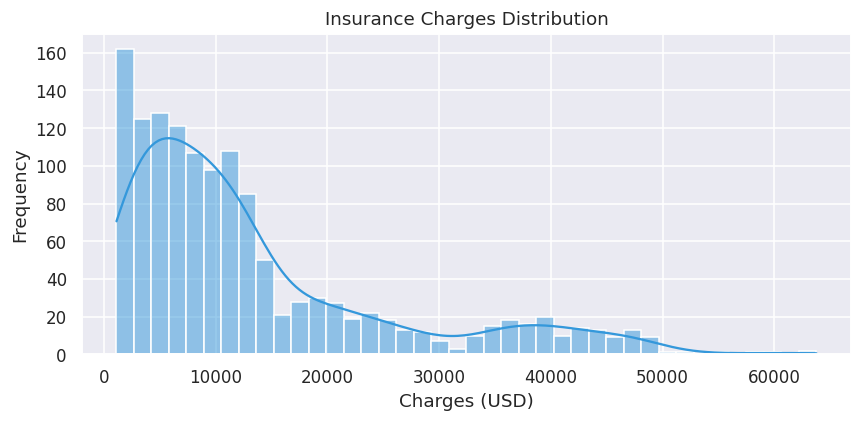

In [6]:
# Histogram of insurance charges with KDE overlay
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=40, color='#3498DB', kde=True)
plt.title('Insurance Charges Distribution')
plt.xlabel('Charges (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

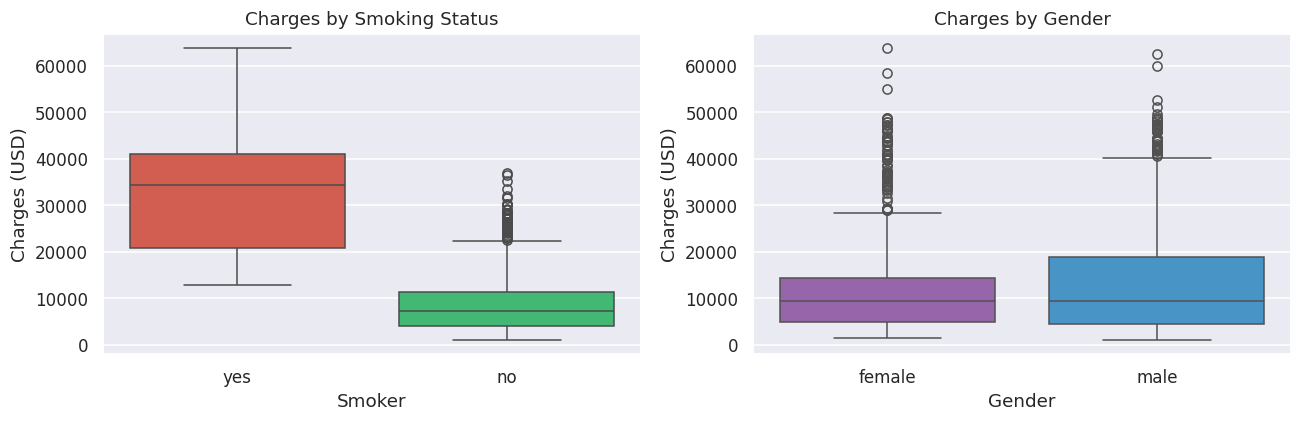

In [7]:
# Box plots comparing charges by smoking status and sex
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0],
            palette={'yes': '#E74C3C', 'no': '#2ECC71'})
axes[0].set_title('Charges by Smoking Status')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges (USD)')

sns.boxplot(data=df, x='sex', y='charges', ax=axes[1],
            palette={'male': '#3498DB', 'female': '#9B59B6'})
axes[1].set_title('Charges by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Charges (USD)')

plt.tight_layout()
plt.show()

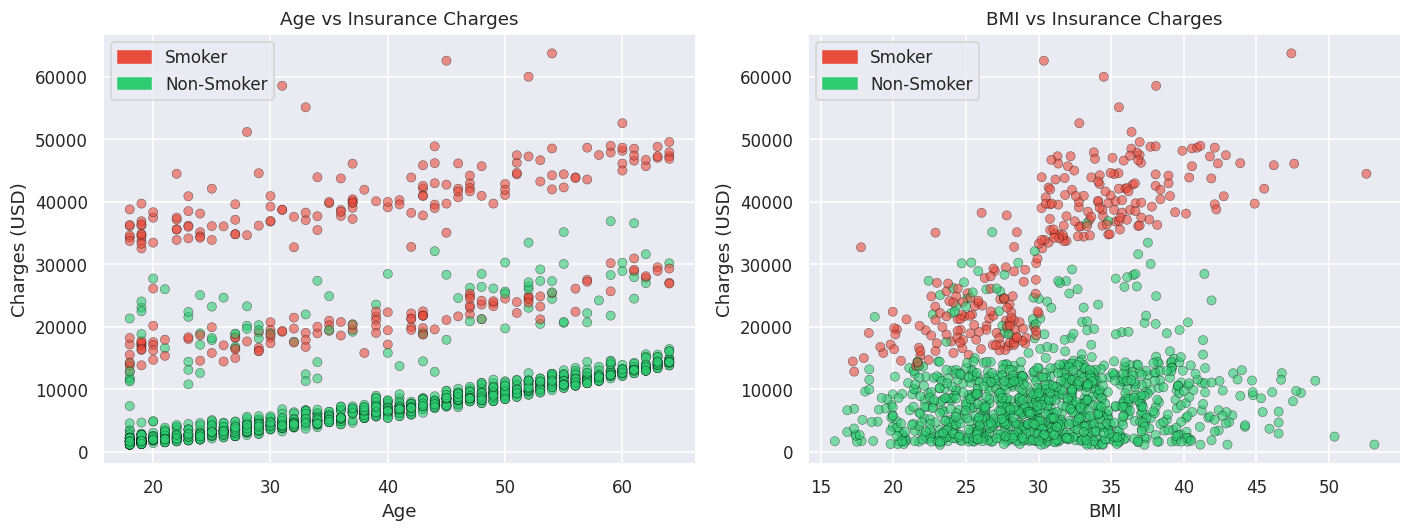

In [8]:
# Scatter plots linking age and BMI to insurance charges
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = df['smoker'].map({'yes': '#E74C3C', 'no': '#2ECC71'})

axes[0].scatter(df['age'], df['charges'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.3)
axes[0].set_title('Age vs Insurance Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges (USD)')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#E74C3C', label='Smoker'), Patch(color='#2ECC71', label='Non-Smoker')])

axes[1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.3)
axes[1].set_title('BMI vs Insurance Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges (USD)')
axes[1].legend(handles=[Patch(color='#E74C3C', label='Smoker'), Patch(color='#2ECC71', label='Non-Smoker')])

plt.tight_layout()
plt.show()

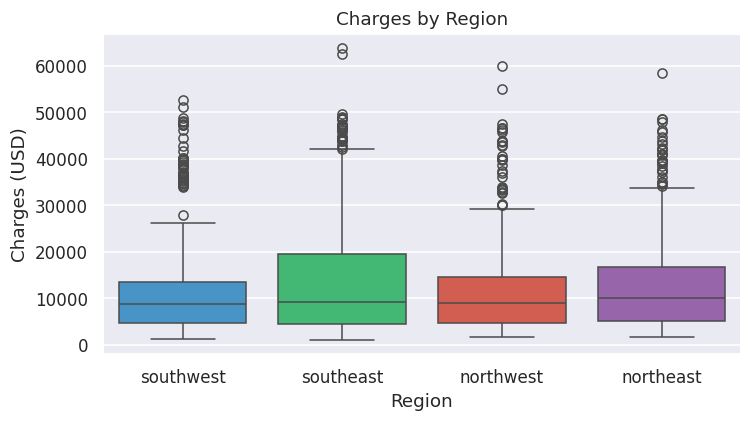

In [9]:
# Regional breakdown of insurance charges
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='region', y='charges',
            palette=['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6'])
plt.title('Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

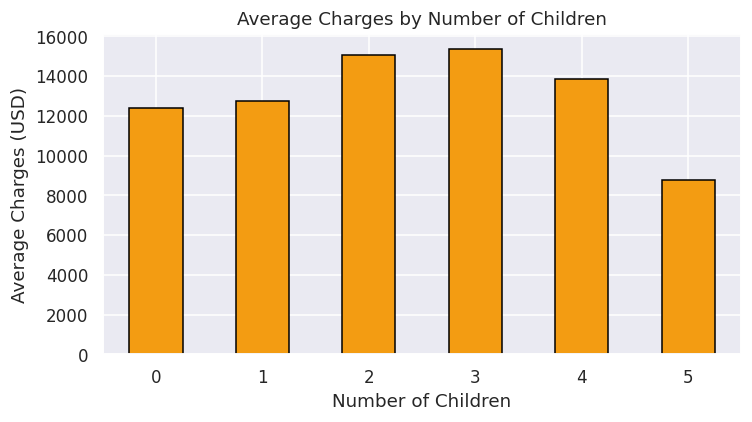

In [10]:
# Mean charge per dependant count
plt.figure(figsize=(7, 4))
df.groupby('children')['charges'].mean().plot(kind='bar', color='#F39C12', edgecolor='black')
plt.title('Average Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Charges (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

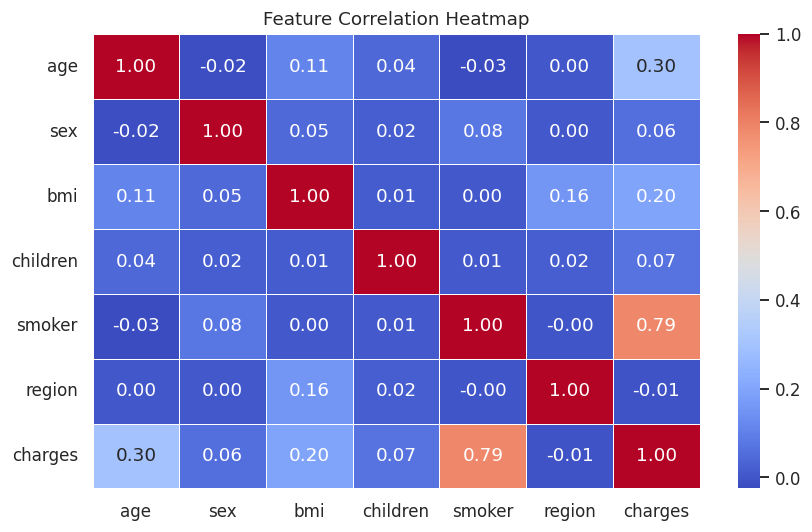

In [11]:
# Heatmap of pairwise feature correlations after encoding
df_corr = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_corr[col] = le.fit_transform(df_corr[col])

plt.figure(figsize=(8, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 5: Data Cleaning & Preprocessing

In [12]:
df_clean = df.copy()

# Apply label encoding to convert text columns to numbers
le = LabelEncoder()
df_clean['sex']    = le.fit_transform(df_clean['sex'])      # female=0, male=1
df_clean['smoker'] = le.fit_transform(df_clean['smoker'])   # no=0, yes=1
df_clean['region'] = le.fit_transform(df_clean['region'])   # encoded 0-3

print('Encoding complete.')
print('Missing values:', df_clean.isnull().sum().sum())
df_clean.head()

Encoding complete.
Missing values: 0


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [13]:
# Separate input features from the prediction target
X = df_clean.drop(columns=['charges'])
y = df_clean['charges']

# Partition data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalise features using standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 1070
Testing samples : 268


## Step 6: Model Training

In [14]:
# Fit a Linear Regression model as the baseline
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print('Linear Regression')
print('MAE  :', round(lr_mae,  2))
print('RMSE :', round(lr_rmse, 2))
print('R2   :', round(lr_r2,   4))

Linear Regression
MAE  : 4186.51
RMSE : 5799.59
R2   : 0.7833


In [15]:
# Train Random Forest — an ensemble-based approach Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('Random Forest Regressor')
print('MAE  :', round(rf_mae,  2))
print('RMSE :', round(rf_rmse, 2))
print('R2   :', round(rf_r2,   4))

Random Forest Regressor
MAE  : 2518.48
RMSE : 4571.5
R2   : 0.8654


## Step 7: Model Evaluation

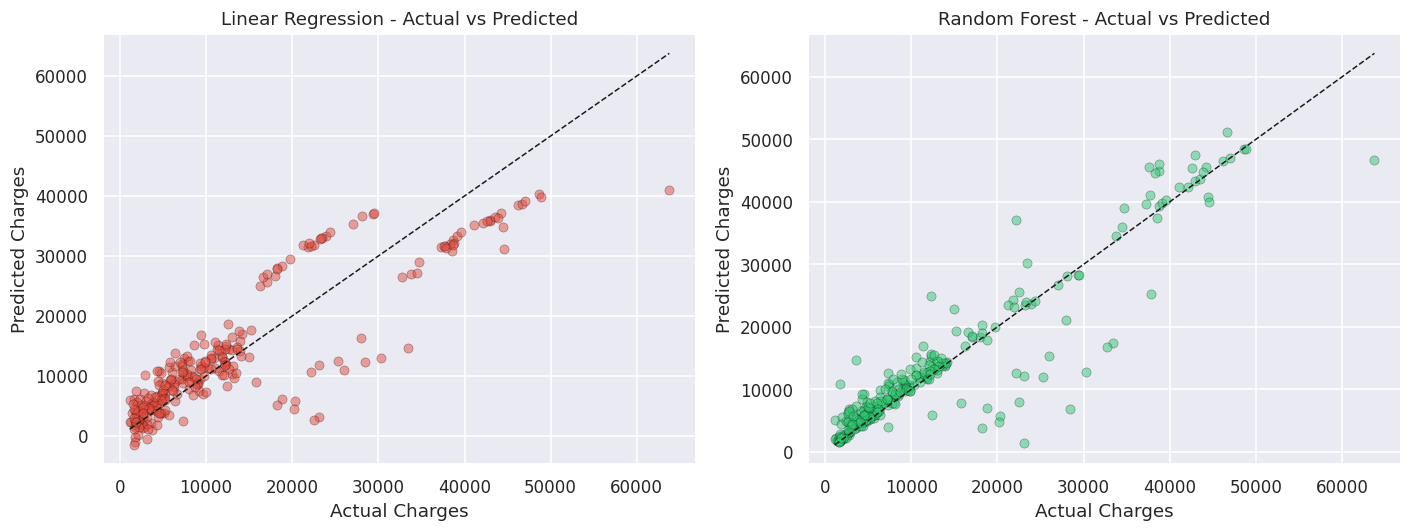

In [16]:
# Scatter plots of actual vs predicted charges for each model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, lr_pred, alpha=0.5, color='#E74C3C', edgecolors='black', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[0].set_title('Linear Regression - Actual vs Predicted')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')

axes[1].scatter(y_test, rf_pred, alpha=0.5, color='#2ECC71', edgecolors='black', linewidth=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[1].set_title('Random Forest - Actual vs Predicted')
axes[1].set_xlabel('Actual Charges')
axes[1].set_ylabel('Predicted Charges')

plt.tight_layout()
plt.show()

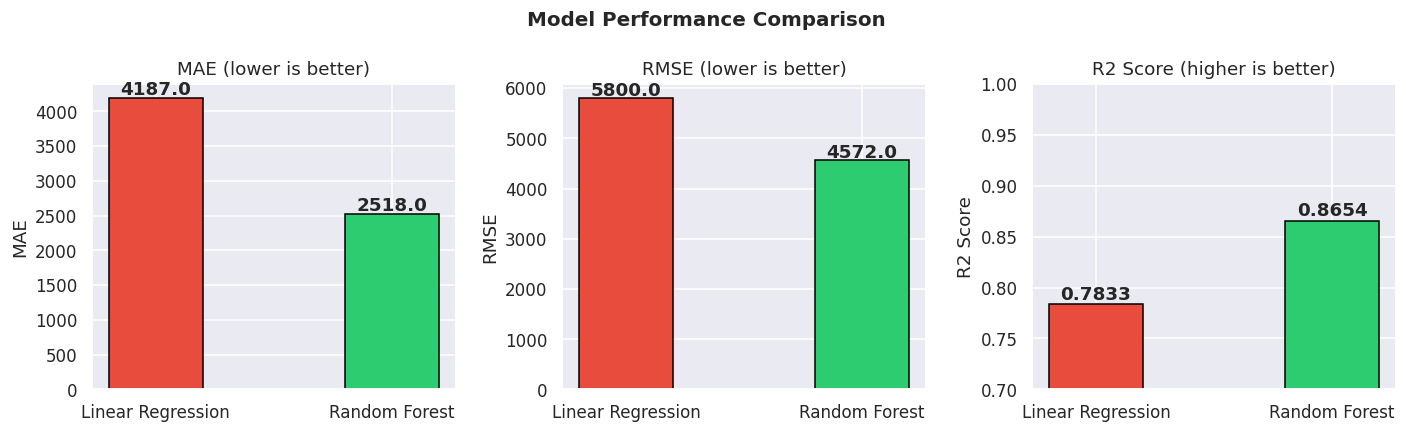

In [17]:
# Bar charts comparing MAE, RMSE, and R² across models
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
model_names = ['Linear Regression', 'Random Forest']
bar_colors  = ['#E74C3C', '#2ECC71']

axes[0].bar(model_names, [lr_mae,  rf_mae],  color=bar_colors, edgecolor='black', width=0.4)
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('MAE')
for i, v in enumerate([lr_mae, rf_mae]):
    axes[0].text(i, v + 50, str(round(v, 0)), ha='center', fontweight='bold')

axes[1].bar(model_names, [lr_rmse, rf_rmse], color=bar_colors, edgecolor='black', width=0.4)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE')
for i, v in enumerate([lr_rmse, rf_rmse]):
    axes[1].text(i, v + 50, str(round(v, 0)), ha='center', fontweight='bold')

axes[2].bar(model_names, [lr_r2,   rf_r2],   color=bar_colors, edgecolor='black', width=0.4)
axes[2].set_title('R2 Score (higher is better)')
axes[2].set_ylabel('R2 Score')
axes[2].set_ylim(0.7, 1.0)
for i, v in enumerate([lr_r2, rf_r2]):
    axes[2].text(i, v + 0.005, str(round(v, 4)), ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

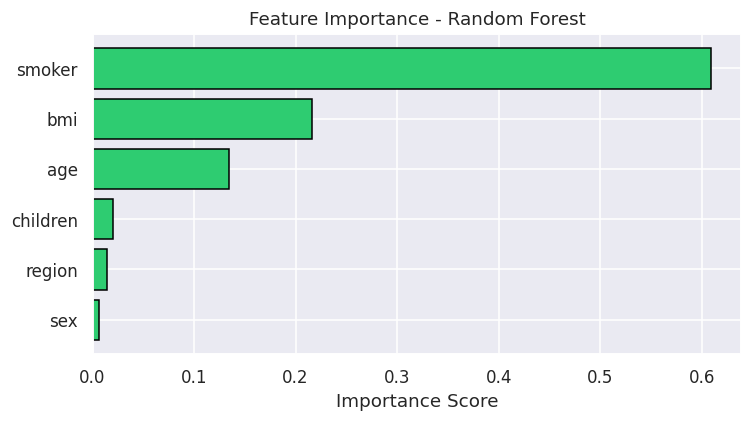

In [18]:
# Bar chart of feature contribution scores - Random Forest
feat_imp = pd.DataFrame({
    'Feature'   : X.columns.tolist(),
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2ECC71', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 8: Conclusion

In [19]:
best     = 'Random Forest' if rf_r2 >= lr_r2 else 'Linear Regression'
best_r2  = max(rf_r2, lr_r2)
best_mae = rf_mae if rf_r2 >= lr_r2 else lr_mae

print('Model Comparison:')
comparison = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'MAE'     : [round(lr_mae,  2), round(rf_mae,  2)],
    'RMSE'    : [round(lr_rmse, 2), round(rf_rmse, 2)],
    'R2 Score': [round(lr_r2,   4), round(rf_r2,   4)]
})
print(comparison.to_string(index=False))
print(f'\nBetter Model: {best}')
print('\nKey Findings:')
print('  - Smoking status is the single most influential factor on insurance charges.')
print('  - Smokers pay significantly higher charges than non-smokers.')
print('  - Age and BMI also have a strong positive correlation with charges.')
print('  - Customers with BMI above 30 (obese) and who smoke have the highest charges.')
print('  - Region and gender have relatively low impact on charges.')
print(f'  - {best} achieved better prediction with R2 = {best_r2:.4f} and MAE = {best_mae:.2f}.')

Model Comparison:
            Model     MAE    RMSE  R2 Score
Linear Regression 4186.51 5799.59    0.7833
    Random Forest 2518.48 4571.50    0.8654

Better Model: Random Forest

Key Findings:
  - Smoking status is the single most influential factor on insurance charges.
  - Smokers pay significantly higher charges than non-smokers.
  - Age and BMI also have a strong positive correlation with charges.
  - Customers with BMI above 30 (obese) and who smoke have the highest charges.
  - Region and gender have relatively low impact on charges.
  - Random Forest achieved better prediction with R2 = 0.8654 and MAE = 2518.48.
